# **Credit Card Fraud Detection(Выявление мошенничества с кредитными картами)**

**Ссылка:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

# **Описание задачи.**
Рост популярности безналичных платежей сопровождается увеличением числа мошеннических операций с кредитными картами. Это создает серьезные риски как для клиентов, которые могут потерять свои средства, так и для финансовых учреждений, несущих репутационные и финансовые убытки. Своевременное обнаружение мошенничества является ключевой задачей для обеспечения безопасности транзакций.

Набор данных содержит информацию о транзакциях с кредитными картами, совершенных европейскими держателями карт. Он включает как легитимные, так и мошеннические операции.

# **Описание датасета с сайта Kaggle.**
Набор данных содержит транзакции, совершенные по кредитным картам европейскими держателями карт в сентябре 2013 года.
В этом наборе данных представлены транзакции за два дня, среди которых 492 из 284 807 являются мошенническими. Набор данных сильно несбалансирован: положительный класс (мошеннические операции) составляет всего 0.172% от всех транзакций.

Он содержит только числовые входные переменные, которые являются результатом преобразования методом главных компонент (PCA). К сожалению, из-за соображений конфиденциальности мы не можем предоставить исходные признаки и более подробную информацию о данных. Признаки V1, V2, … V28 — это главные компоненты, полученные с помощью PCA. Единственные признаки, которые не были преобразованы, — это 'Time' (Время) и 'Amount' (Сумма). Признак 'Time' содержит количество секунд, прошедших между текущей транзакцией и первой транзакцией в наборе данных. Признак 'Amount' — это сумма транзакции; этот признак можно использовать для обучения, чувствительного к «стоимости» ошибки (example-dependant cost-sensitive learning). Признак 'Class' является целевой переменной и принимает значение 1 в случае мошенничества и 0 в ином случае.

Учитывая сильный дисбаланс классов, для оценки качества модели рекомендуется использовать метрику «Площадь под кривой Точность-Полнота» (Area Under the Precision-Recall Curve, AUPRC). Стандартная метрика точности (accuracy), рассчитанная по матрице ошибок, не является показательной для задач несбалансированной классификации.

# **Какие выводы мы можем сделать?**
На основе предоставленного описания мы уже можем сделать несколько критически важных выводов, которые определят весь дальнейший процесс анализа(что показывает важность ознакомления с информацие по данным перед началовм работы)

1.  **Сильнейший дисбаланс классов.** Это самая главная особенность. Мошеннических транзакций всего 0.172% (492 из 284 807).
    *   **Что это значит:** Модель, которая всегда будет предсказывать "не мошенничество" (класс 0), будет иметь точность (accuracy) 99.828%. Однако такая модель будет абсолютно бесполезной. Поэтому стандартная метрика accuracy здесь не подходит.
    *   **Что делать:** Необходимо использовать специализированные метрики, как и рекомендуется в описании — AUPRC (Area Under the Precision-Recall Curve). Также подойдут F1-score, Recall (полнота) и Precision (точность).

2.  **Анонимность данных.** Большинство признаков (V1-V28) являются результатом преобразования PCA (метод главных компонент).
    *   **Что это значит:** Мы не знаем, что изначально означали эти признаки (например, страна, тип транзакции, время суток). Это защищает конфиденциальность, но лишает нас возможности проводить "интуитивный" анализ и создавать новые признаки на основе имеющейся информации.
    *   **Что делать:** Придется работать с данными "как есть", полагаясь на математические зависимости, которые сможет найти модель. Предварительная обработка данных упрощается, так как все признаки уже числовые и, вероятно, масштабированы.

3.  **Есть два "сырых" признака.** Time и Amount не были преобразованы.
    *   **Что это значит:** Эти признаки имеют ясный физический смысл. Amount (сумма транзакции) почти наверняка является важным предиктором. Time (время) показывает разницу во секундах между текущей и самой первой транзакциями, вероятно, этот признак не является информативным.
    *   **Что делать:** Эти два столбца, скорее всего, потребуют масштабирования (например, с помощью StandardScaler или RobustScaler), так как их диапазоны значений сильно отличаются от диапазонов признаков V1-V28.

4.  **Задача — бинарная классификация.** Целевая переменная Class имеет только два значения: 1 (мошенничество) и 0 (легитимная операция). Цель — построить модель, которая будет предсказывать это значение.

# **Описание признаков датасета.**

Этот набор данных содержит транзакции, описанные 31 признаком. Большинство из них анонимизированы для защиты конфиденциальности.

### **Непреобразованные признаки.**

Эти два признака представлены в своем исходном виде, без применения PCA.

*   Time (Время): Количество секунд, прошедших между текущей транзакцией и самой первой транзакцией в наборе данных. Этот признак можно использовать для анализа временных зависимостей, например, для выявления закономерностей мошенничества в зависимости от времени суток.

*   Amount (Сумма): Сумма финансовой транзакции. Этот признак важен, так как мошеннические операции могут иметь характерные суммы (либо очень мелкие для проверки, либо очень крупные).

### **Анонимизированные признаки.**

Эти признаки являются результатом преобразования методом главных компонент (PCA) исходных, конфиденциальных данных.

*   V1, V2, V3, ..., V28: 28 анонимизированных признаков, полученных с помощью PCA. Их истинный смысл скрыт, но они представляют собой линейные комбинации исходных характеристик транзакции (таких как время, место, тип товара, данные о карте и т.д.). Преобразование было выполнено для защиты персональных данных. Эти признаки уже отмасштабированы.

### **Целевая переменная.**

Это столбец, который мы пытаемся предсказать.

*   Class (Класс): Целевая переменная, которая указывает, является ли транзакция мошеннической.
        *   1 — транзакция является мошеннической (fraud).
        *   0 — транзакция является легитимной (обычной).
    *   Особенность: Классы сильно несбалансированны. Доля мошеннических транзакций (класс 1) составляет всего **0.172%** от общего числа, что требует особого подхода при построении и оценке модели.

# **Анализ**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Курсовая/creditcard.csv')

In [ ]:
#Посмотрим как выглядит наш датасет
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Размерность датафрейма:", df.shape)

Размерность датафрейма: (284807, 31)


In [ ]:
print("Информация о датафрейме:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# **Проверка баланса классов.**

/tmp/ipykernel_7050/654030261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=palette_colors, edgecolor='black')
/tmp/ipykernel_7050/654030261.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


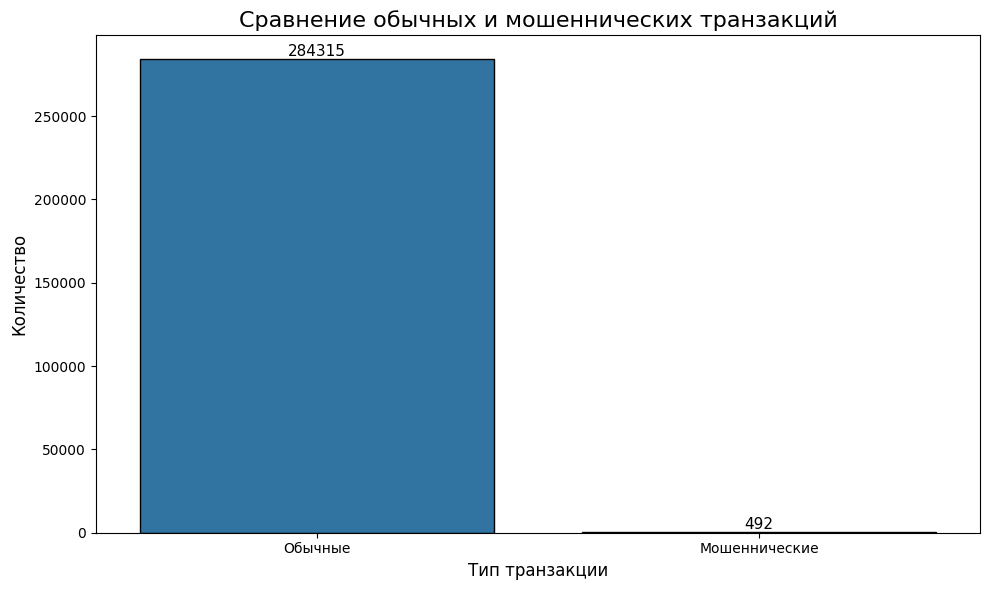

In [ ]:
palette_colors = ['#1f77b4', '#d62728']  # синий (Обычные), красный (Мошеннические)
labels = ['Обычные', 'Мошеннические']

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='Class', data=df, palette=palette_colors, edgecolor='black')
ax.set_title('Сравнение обычных и мошеннических транзакций', fontsize=16)
ax.set_xticklabels(labels)
ax.set_xlabel('Тип транзакции', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.tight_layout()
plt.show()

**Промежуточный итог:**

В наборе данных наблюдается очень высокий дисбаланс классов.

Только 492 записи из 284807 помечены как мошеннические транзакции.
Процент распределения для большинства классов составляет 99.83%, а для меньшинства — 0.17%.

# **Пропуски и дубликаты.**

Прежде чем переходить к моделированию, необходимо выполнить базовую проверку качества данных. Проанализируем датасет на наличие пропущенных значений и полных дубликатов строк, так как их присутствие может исказить результаты анализа и снизить производительность будущей модели.

In [ ]:
df.isnull().values.any() #проверим на пропуски

np.False_

In [ ]:
df.duplicated().sum() #проверка на дубликаты

np.int64(1081)

In [ ]:
duplicated_rows = df[df.duplicated(keep=False)]
# keep=False покажет все вхождения дублирующихся строк

# Проверить, какие классы у этих дубликатов
print(duplicated_rows['Class'].value_counts())

Class
0    1822
1      32
Name: count, dtype: int64


In [ ]:
print("Исходный размер датафрейма:", df.shape)

df_no_duplicates = df.drop_duplicates(keep='first', inplace=False) # удаляем дубликаты

print("Размер после удаления дубликатов:", df_no_duplicates.shape)
print("Оставшиеся дубликаты:", df_no_duplicates.duplicated().sum())

Исходный размер датафрейма: (284807, 31)
Размер после удаления дубликатов: (283726, 31)
Оставшиеся дубликаты: 0


**Промежуточный итог:**

*   Пропуски отсутствуют.
*   Обнаружено и удалено 1854 полных дубликата строк(1822 — обычные транзакции (Class=0); 32 — мошеннические транзакции (Class=1)). Датасет очищен от дубликатов для корректного обучения и оценки модели.

Теперь надо разобраться с выбросами.



# **Выбросы.**

Теперь проанализируем данные на наличие выбросов. Визуализация с помощью диаграмм — отличный способ оценить распределение каждого признака и наглядно увидеть значения, которые сильно отклоняются от большинства наблюдений.

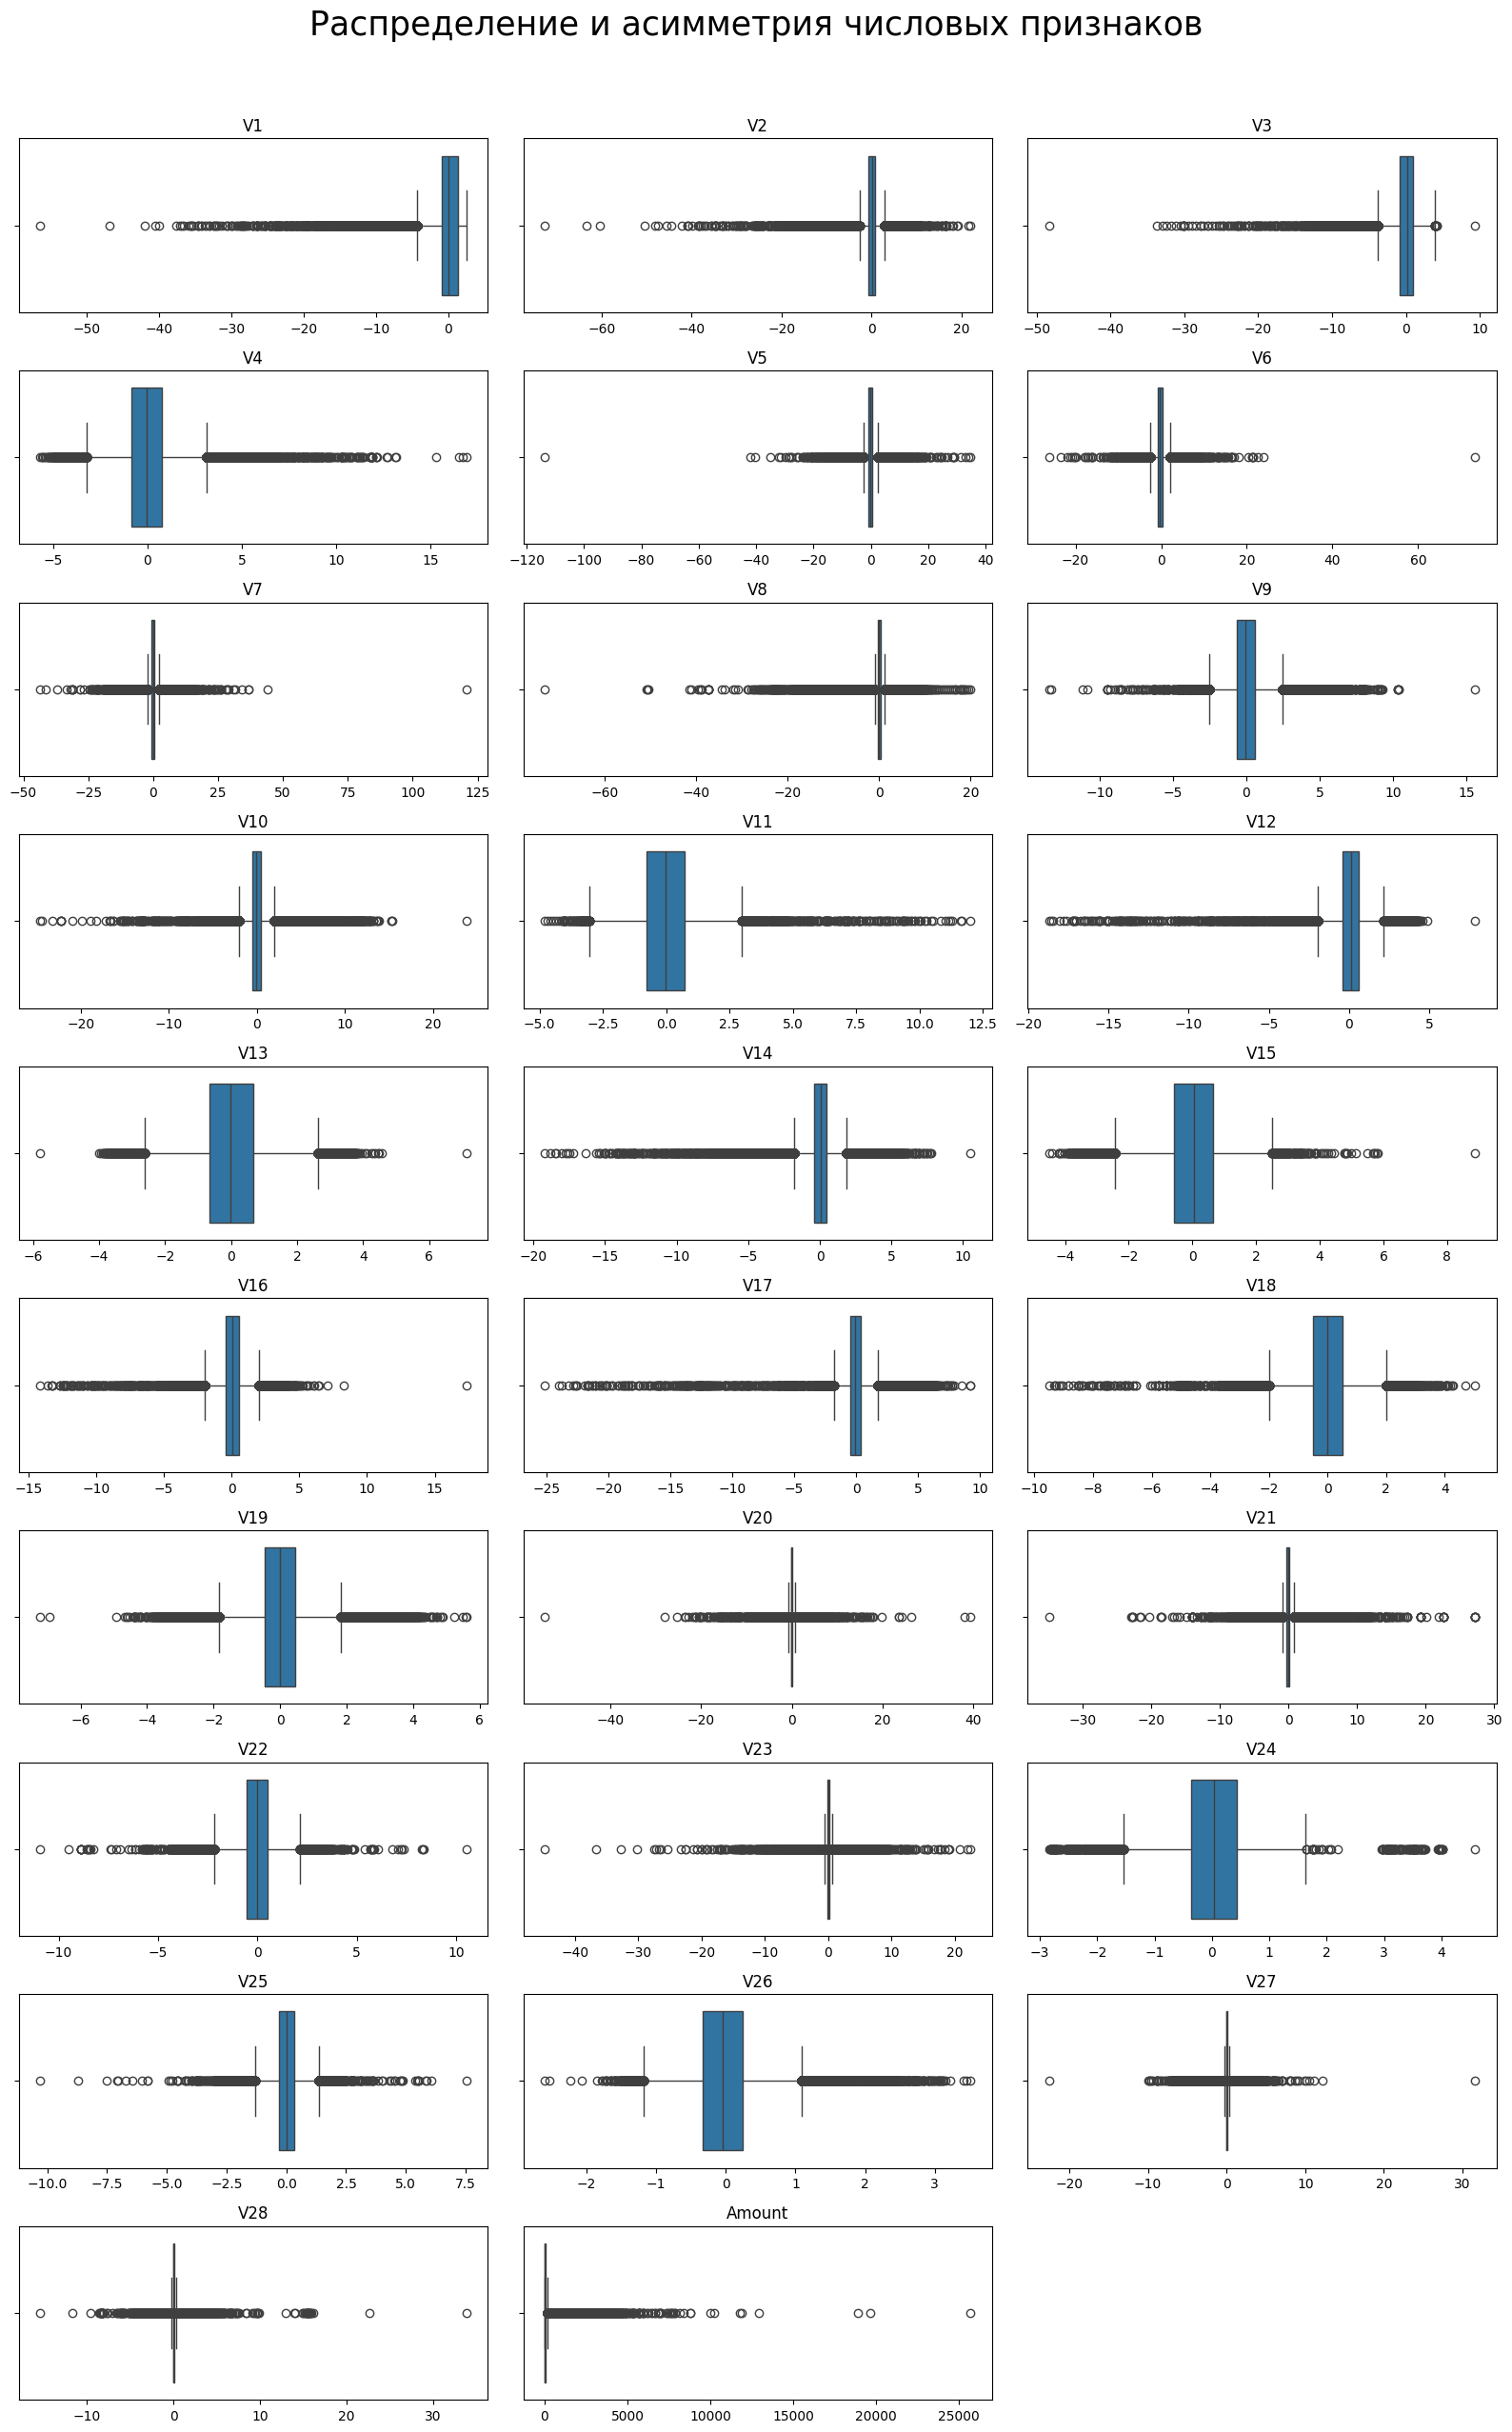

In [ ]:
numeric_columns = df.loc[:, 'V1':'Amount'].columns.tolist()

def plot_custom_boxplots(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, figsize=(16, 25))
    fig.suptitle(suptitle, y=1.02, size=25)
    axs = axs.flatten()

    num_plots = min(len(columns_list), len(axs))

    for i in range(num_plots):
        column_name = columns_list[i]

        sns.boxplot(data=dataset, x=column_name, orient='h', ax=axs[i], color='#1f77b4') # Используем наш синий цвет

        axs[i].set_title(f'{column_name}')
        axs[i].set_xlabel('')

    for i in range(num_plots, len(axs)):
        axs[i].set_visible(False)

    plt.tight_layout()
    plt.show()



plot_custom_boxplots(dataset=df,
                     columns_list=numeric_columns,
                     rows=10,
                     cols=3,
                     suptitle='Распределение и асимметрия числовых признаков')


**Промежуточный итог:**

Анализ boxplot-ов позволяет сделать несколько ключевых выводов о структуре данных:

*   Наличие многочисленных выбросов: Практически у каждого признака наблюдается большое количество точек, лежащих далеко за пределами основного межквартильного размаха. В контексте задачи обнаружения мошенничества, эти точки, скорее всего, не являются "шумом" или ошибками, а представляют собой аномальные транзакции, которые и являются нашей целью.

*    Выраженная асимметрия: Признаки, такие как V28 и особенно Amount, демонстрируют сильную правостороннюю асимметрию. Это означает, что большинство значений сгруппировано слева, но есть длинный "хвост" из очень больших значений.

Итог: Такая структура данных может негативно сказаться на производительности многих моделей машинного обучения, которые чувствительны к масштабу признаков. Стандартное масштабирование (StandardScaler) будет неэффективным из-за влияния выбросов на среднее значение. Поэтому следующим обязательным шагом является применение робастного масштабирования (RobustScaler), которое устойчиво к выбросам и позволит корректно подготовить данные для моделирования.

# **Распределение признаков.**

Теперь проведем один из ключевых этапов исследовательского анализа: визуализируем распределения признаков в разрезе целевой переменной. Это позволит нам увидеть, какие из них наиболее сильно отличают мошеннические транзакции от обычных.

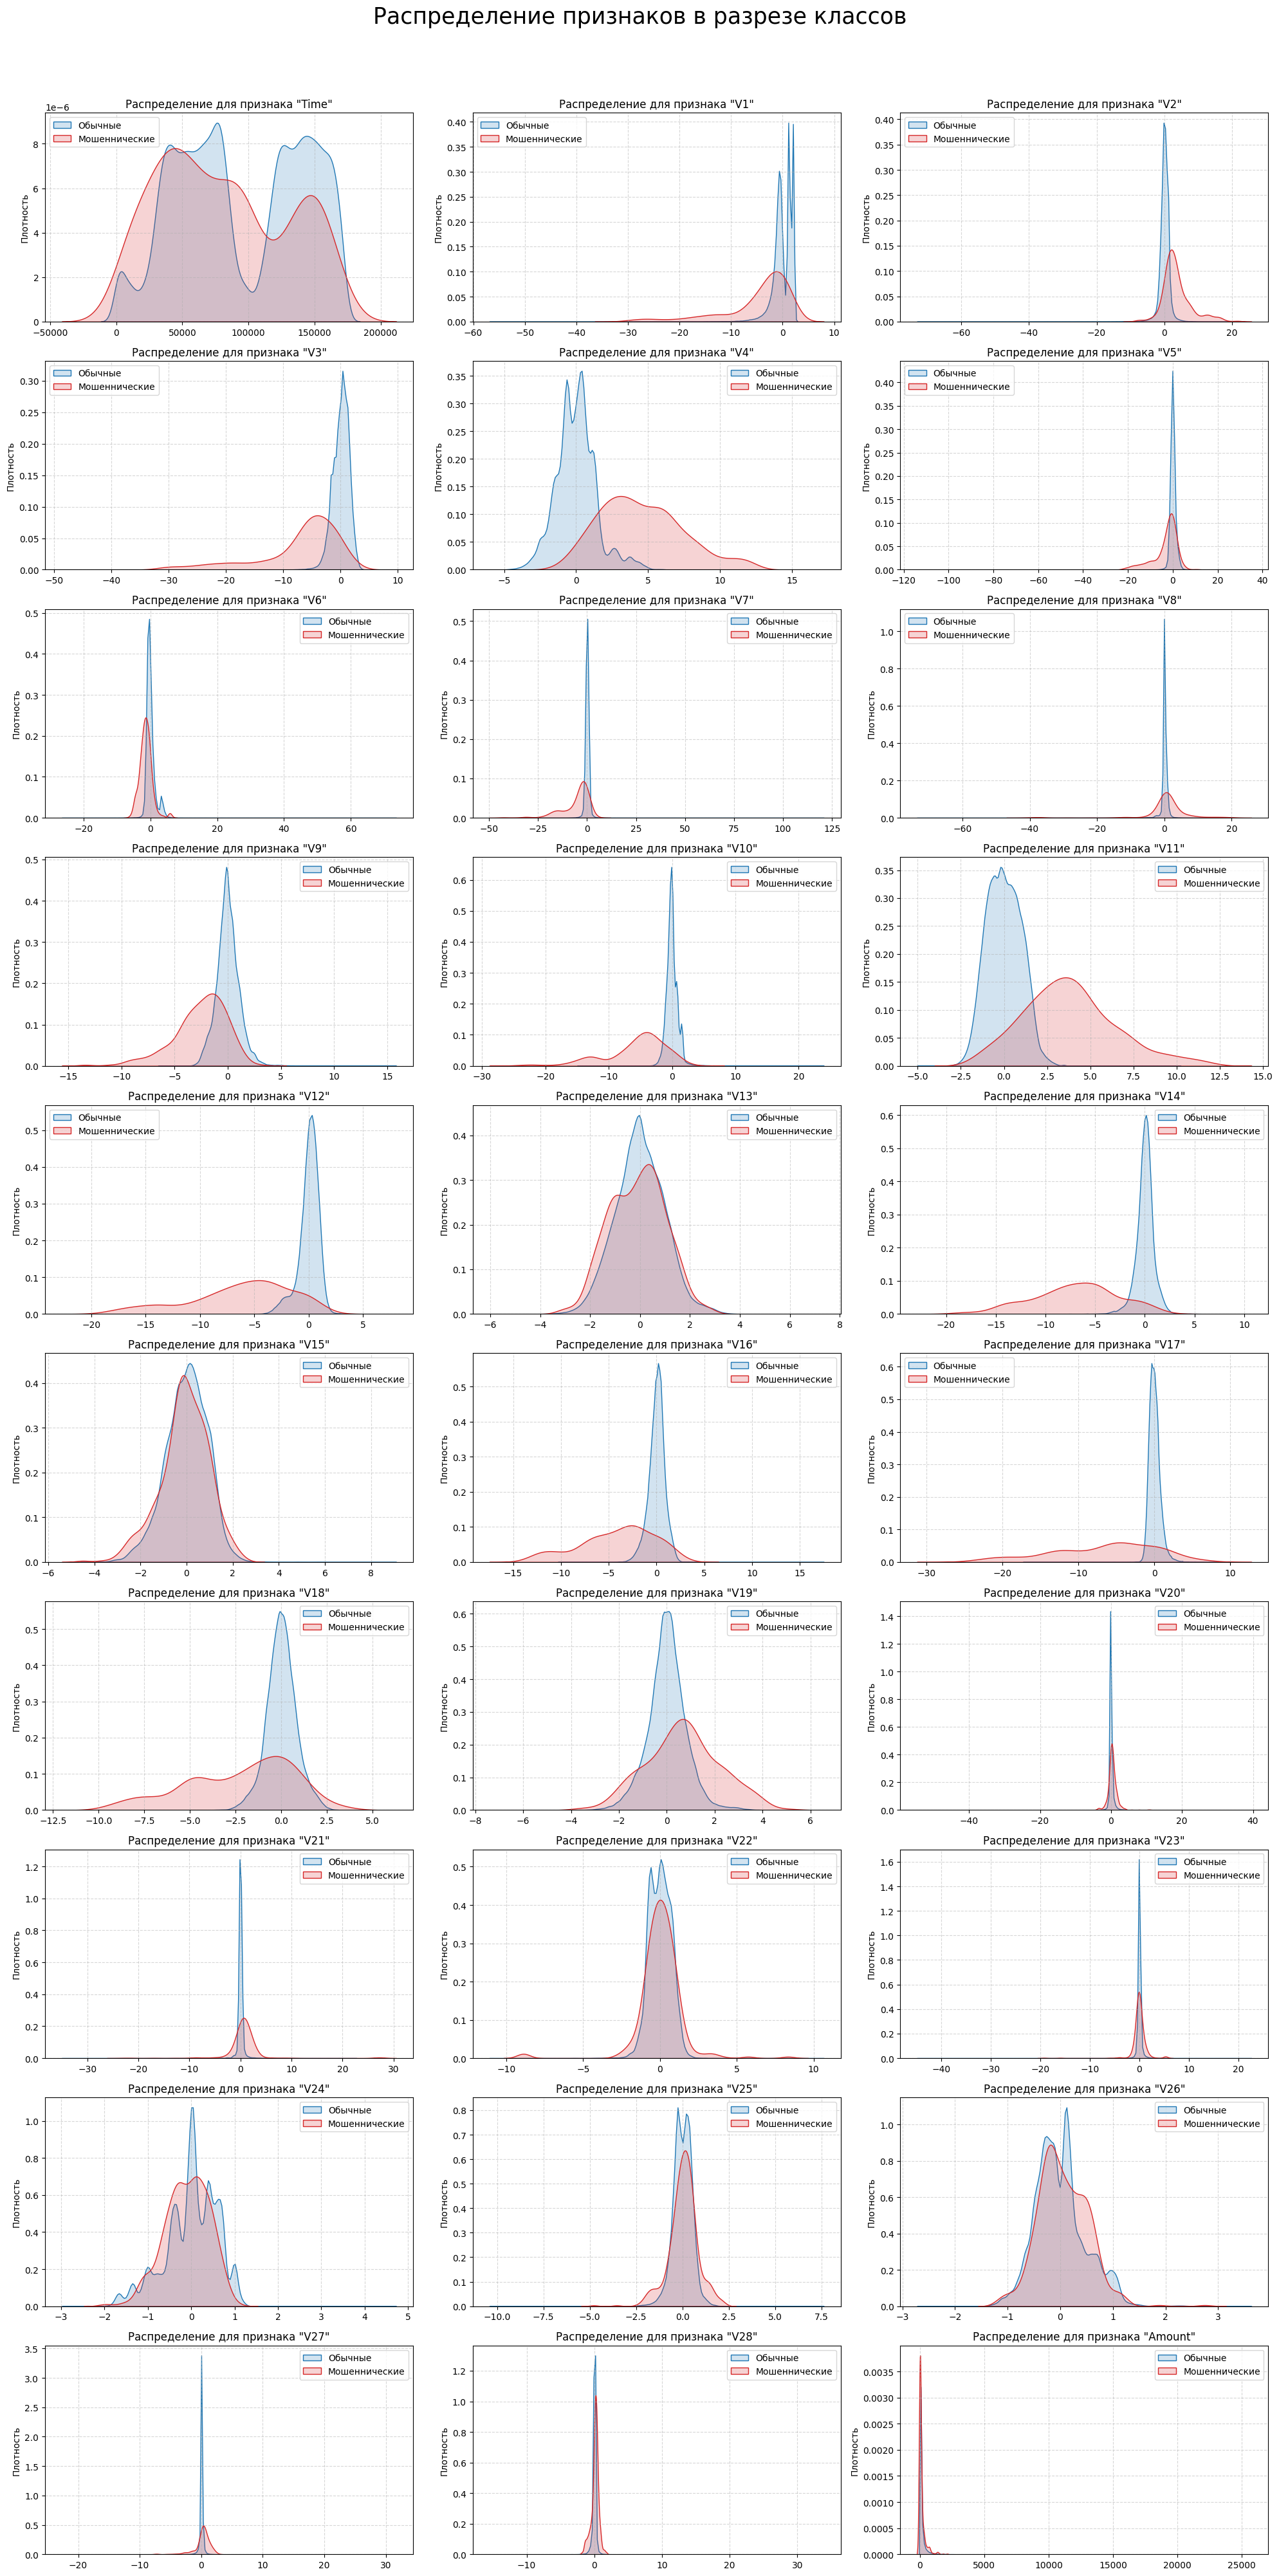

In [ ]:
def plot_kde_distributions(df, suptitle):
    palette_colors = ['#1f77b4', '#d62728']  # синий (Обычные), красный (Мошеннические)
    class_labels = {0: 'Обычные', 1: 'Мошеннические'}

    features = df.drop('Class', axis=1).columns

    df_class_0 = df[df['Class'] == 0]
    df_class_1 = df[df['Class'] == 1]

    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle(suptitle, fontsize=25, y=1.0)
    axs = axs.flatten()

    for i, feature in enumerate(features):
        ax = axs[i]

        sns.kdeplot(df_class_0[feature], ax=ax, color=palette_colors[0],
                    label=class_labels[0], fill=True, alpha=0.2)

        sns.kdeplot(df_class_1[feature], ax=ax, color=palette_colors[1],
                    label=class_labels[1], fill=True, alpha=0.2)

        ax.set_title(f'Распределение для признака "{feature}"', fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('Плотность')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    for i in range(n_features, len(axs)):
        axs[i].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()



plot_kde_distributions(df, suptitle='Распределение признаков в разрезе классов')

Распределения для обоих классов перекрываются, но что гораздо важнее — они имеют разную структуру. Обычные транзакции сгруппированы очень плотно, в то время как мошеннические показывают значительно больший разброс и часто находятся в "хвостах" распределений. Это говорит о том, что признаки информативны, и у модели есть хорошие шансы на успешную классификацию.

# **Распределение транзакций по времени и сумме.**

Теперь посмотрим на два признака, которые не были затронуты PCA - 'Time' и 'Amount'. Надо визуально оценить, как по ним распределяются мошеннические и обычные транзакции, чтобы найти возможные закономерности.

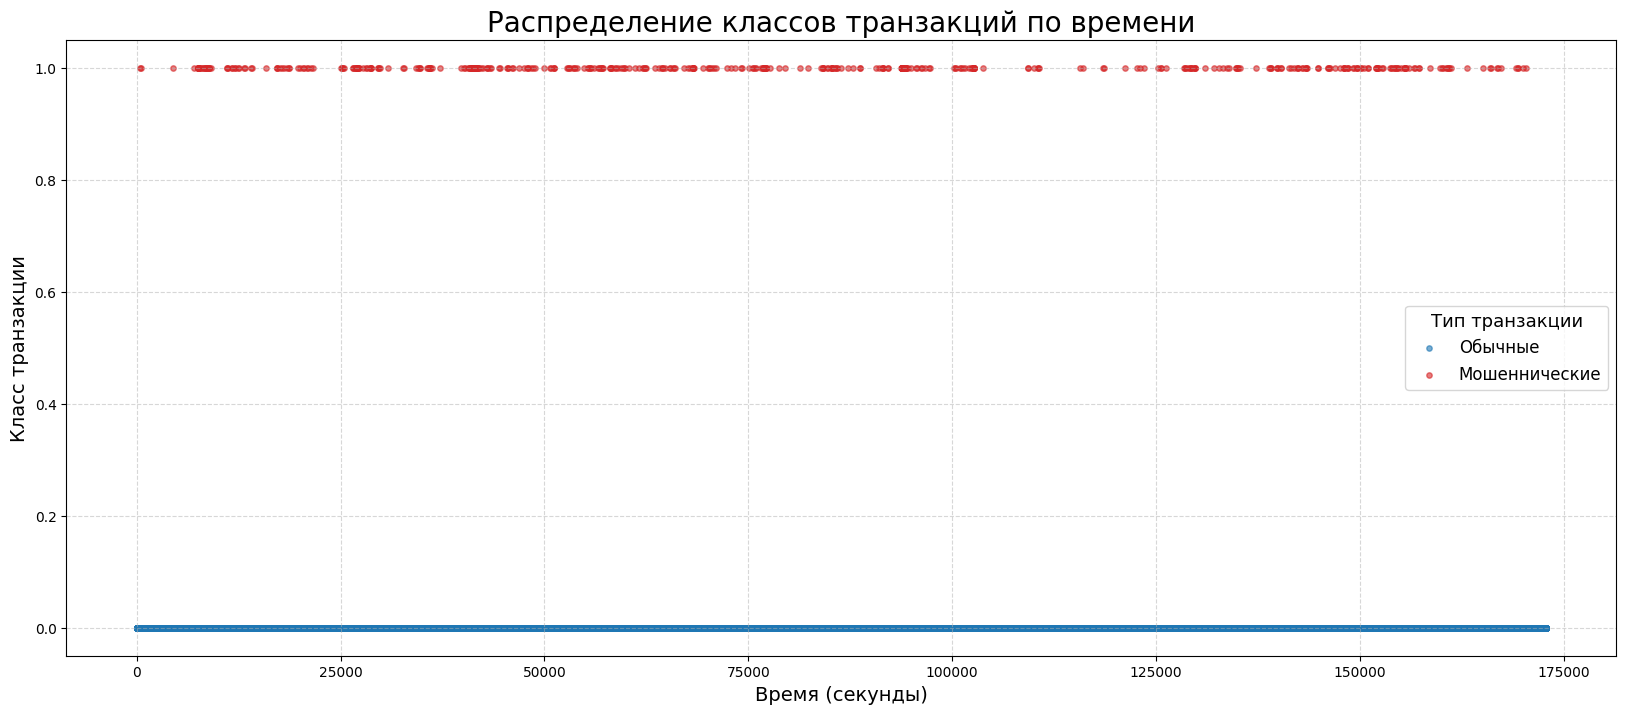

In [ ]:
palette_colors = ['#1f77b4', '#d62728'] # Синий для обычных, красный для мошеннических

fig, ax = plt.subplots(figsize=(20, 8))

normal_transactions = df[df['Class'] == 0]
ax.scatter(x=normal_transactions['Time'], y=normal_transactions['Class'],
           color=palette_colors[0], label='Обычные', alpha=0.6, s=15)

fraud_transactions = df[df['Class'] == 1]
ax.scatter(x=fraud_transactions['Time'], y=fraud_transactions['Class'],
           color=palette_colors[1], label='Мошеннические', alpha=0.6, s=15)

ax.set_title("Распределение классов транзакций по времени", fontsize=20)
ax.set_xlabel("Время (секунды)", fontsize=14)

ax.set_ylabel("Класс транзакции", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

legend = ax.legend(title='Тип транзакции', fontsize=12)
legend.get_title().set_fontsize('13')

plt.show()

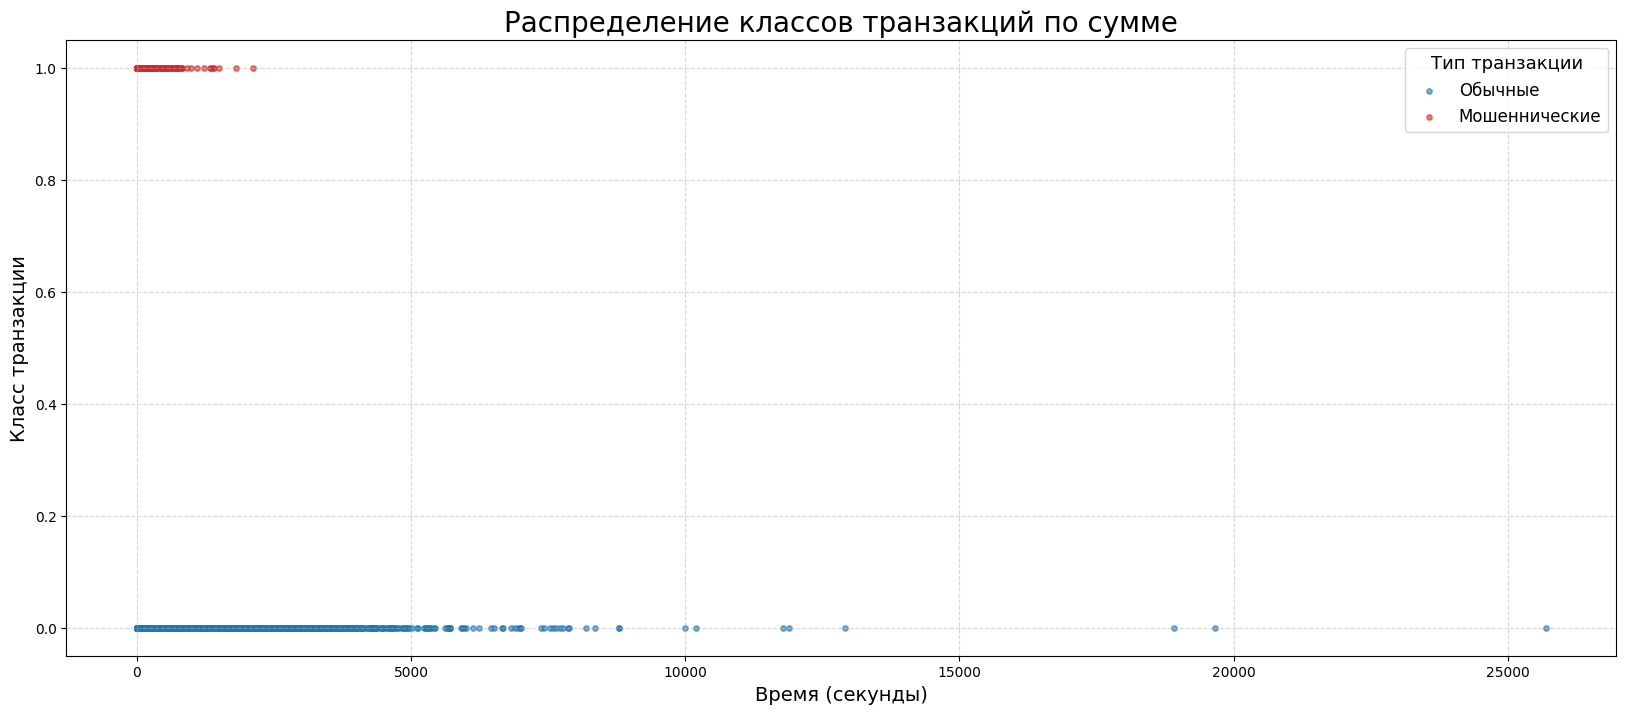

In [ ]:
palette_colors = ['#1f77b4', '#d62728'] # Синий для обычных, красный для мошеннических

fig, ax = plt.subplots(figsize=(20, 8))

normal_transactions = df[df['Class'] == 0]
ax.scatter(x=normal_transactions['Amount'], y=normal_transactions['Class'],
           color=palette_colors[0], label='Обычные', alpha=0.6, s=15) # s - размер точек

fraud_transactions = df[df['Class'] == 1]
ax.scatter(x=fraud_transactions['Amount'], y=fraud_transactions['Class'],
           color=palette_colors[1], label='Мошеннические', alpha=0.6, s=15)

ax.set_title("Распределение классов транзакций по сумме", fontsize=20)
ax.set_xlabel("Время (секунды)", fontsize=14)

ax.set_ylabel("Класс транзакции", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

legend = ax.legend(title='Тип транзакции', fontsize=12)
legend.get_title().set_fontsize('13')

plt.show()

**Промежуточный итог:**

*   Видно, что транзакции с низкой суммой с большей вероятностью являются мошенническими, чем транзакции с высокой суммой.

*   Из распределения мошеннических транзакций во времени нельзя сделать много выводов, так как как мошеннические, так и немошеннические транзакции распределены по времени равномерно.

Итог: Колонку Time можно удалить, т.к. признак не является информативным.

# **Корреляционная матрица.**

Теперь проанализируем взаимосвязи в данных. Поскольку признаки V1-V28 являются результатом метода главных компонент (PCA), мы не ожидаем найти сильной линейной корреляции между ними — по своей природе они должны быть ортогональны.

Однако нас интересуют два ключевых аспекта:

*   Связь с исходными данными: Существует ли корреляция между преобразованными V-признаками и оригинальным признаком Amount.
*   Связь с целью: Какие из признаков имеют наиболее выраженную линейную связь с фактом мошенничества (нашей целевой переменной Class). Это поможет выявить наиболее значимые предикторы.

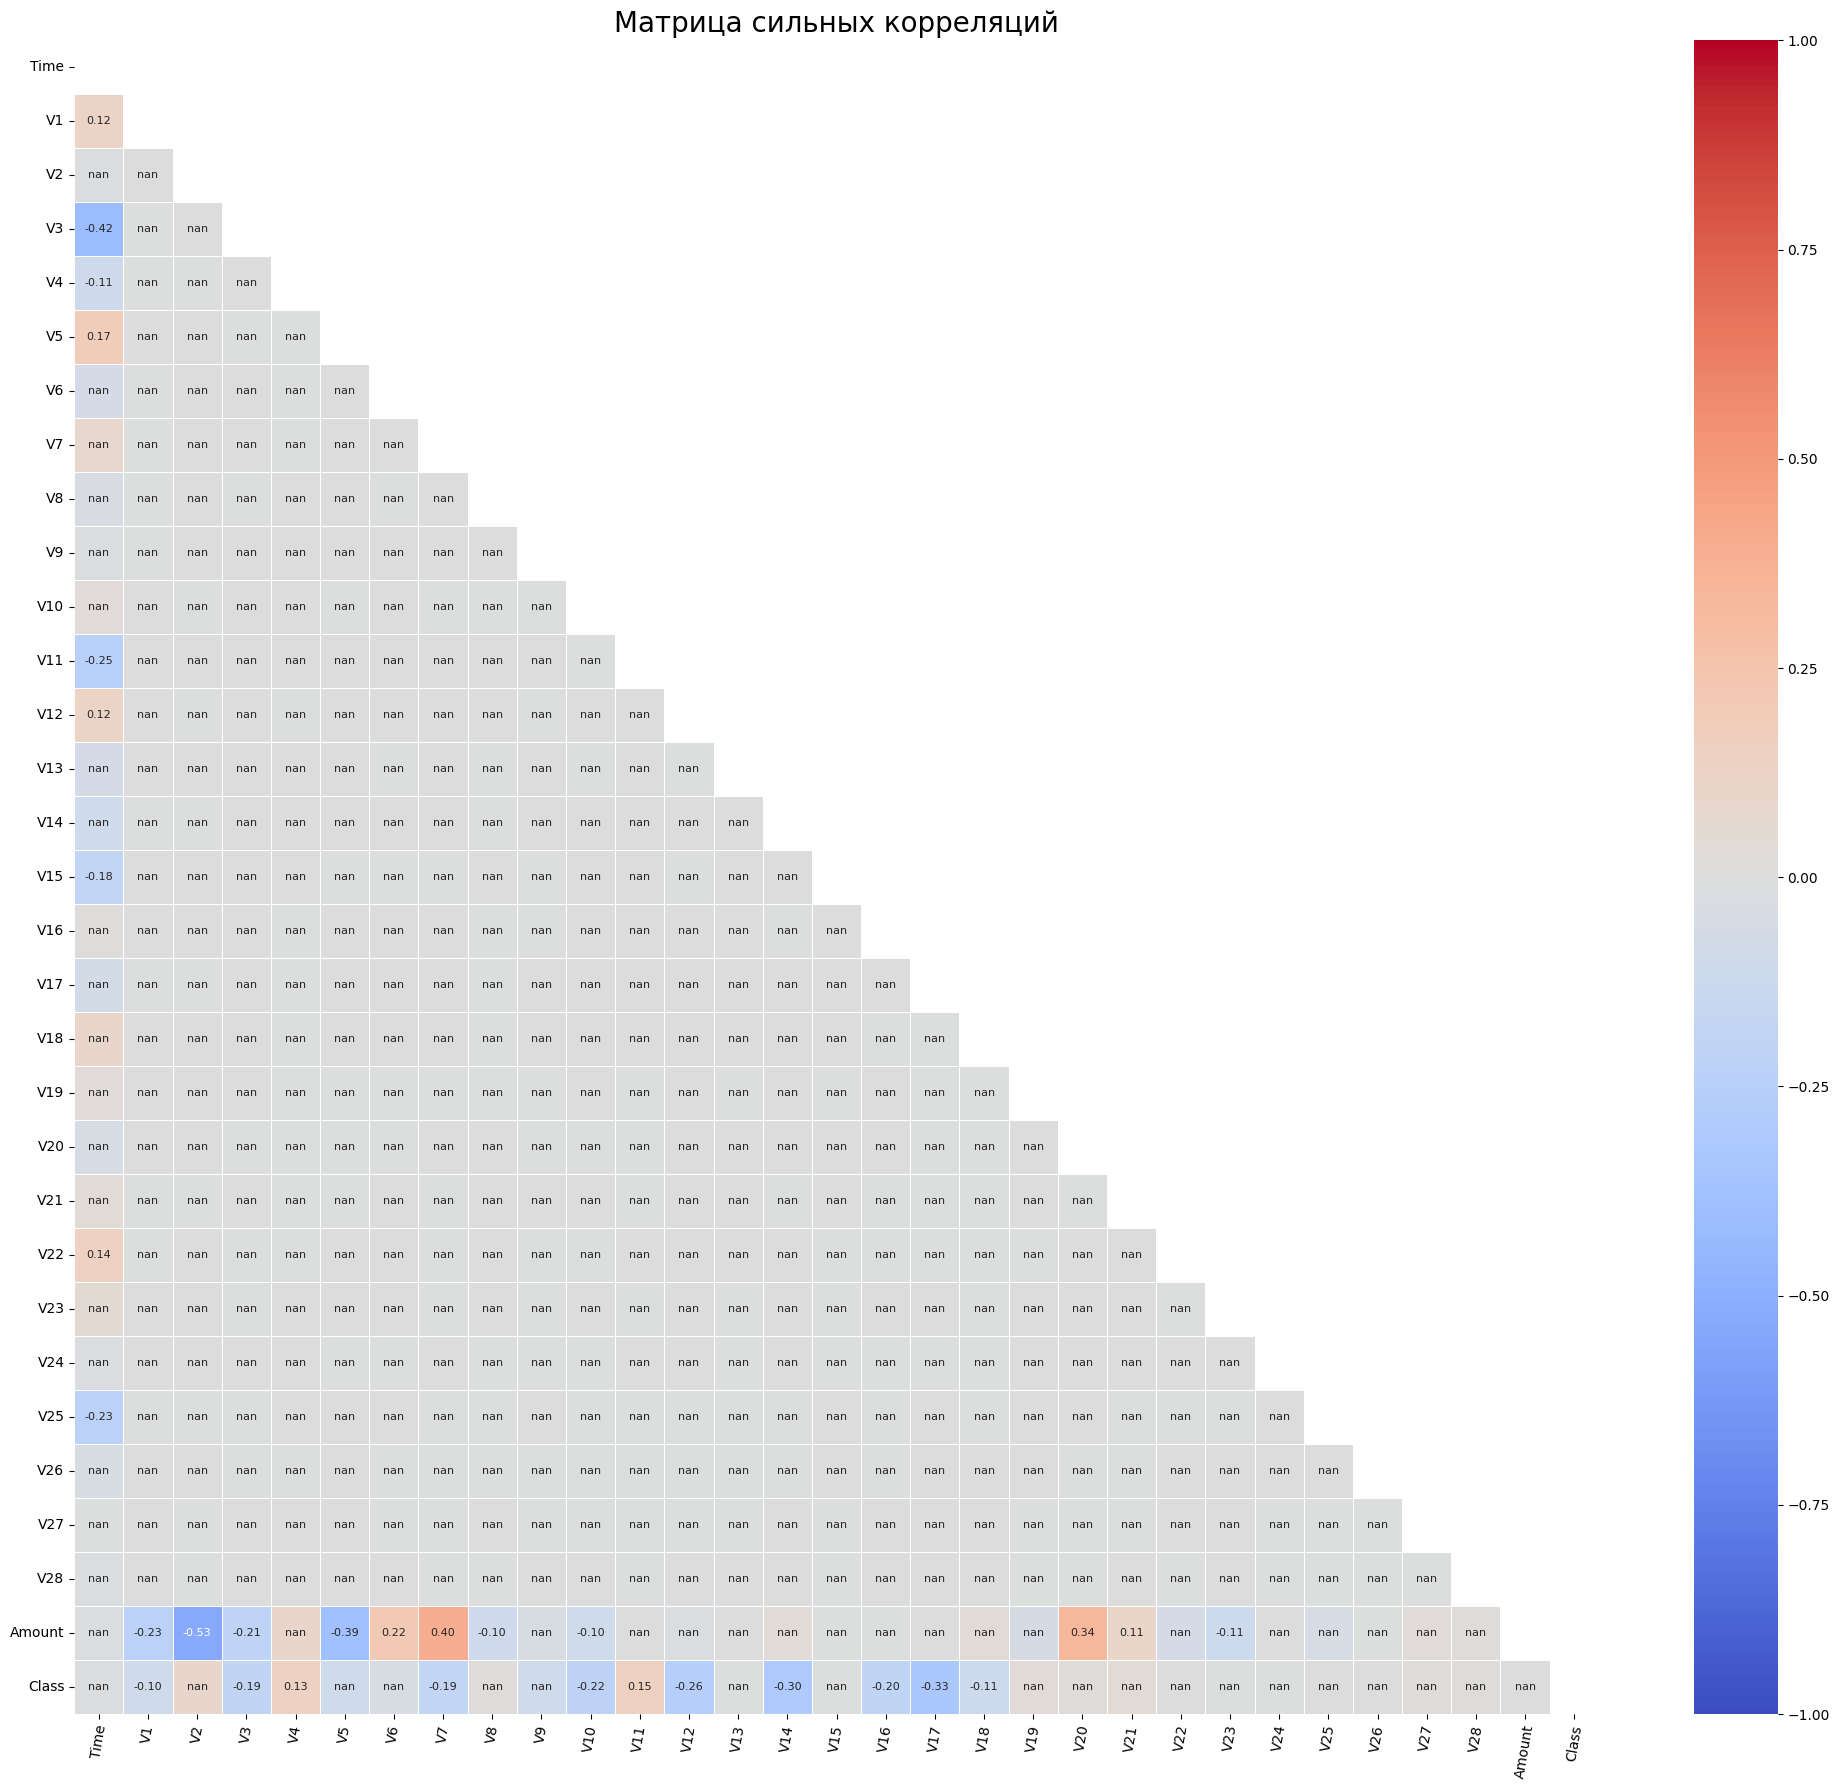

In [ ]:
def plot_seaborn_correlation_matrix_filtered(data, threshold=0.1, title="Матрица сильных корреляций"):
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    annot_data = corr.where(np.abs(corr) > threshold)

    plt.figure(figsize=(20, 18))

    sns.heatmap(corr,
                mask=mask,
                cmap='coolwarm',
                annot=annot_data,
                fmt='.2f',
                annot_kws={'size': 8},
                linewidths=.5,
                vmin=-1, vmax=1)

    plt.title(title, fontsize=20)
    plt.xticks(rotation=80)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()



plot_seaborn_correlation_matrix_filtered(df, threshold=0.1)

**Промежуточный итог:**

Ключевым результатом анализа стало отсутствие(почти) высокой корреляции ( > 0.5) между признаками. Этот результат ожидаем, поскольку переменные V1-V28 являются результатом PCA. Отсутствие мультиколлинеарности — это положительный фактор, который позволяет использовать все признаки для обучения модели без риска избыточности.

# **Итоги и планы.**


### **Итоги анализа.**

Проведенный анализ данных выявил несколько ключевых особенностей, которые будут определять наш подход к моделированию:

1.  **Экстремальный дисбаланс классов:** Это самая важная характеристика датасета. Мошеннические транзакции составляют всего ~0.17% от всех данных. Это означает, что стандартные подходы и метрики (например, Accuracy) будут абсолютно неэффективны.

2.  **Информативность признаков:** Несмотря на то, что признаки V1-V28 анонимизированы (после PCA), анализ их распределений показал отличные новости. Распределения для мошеннических и обычных транзакций имеют принципиально разную форму. Обычные операции формируют узкие пики, в то время как мошеннические имеют более широкое и смещенное распределение. Это сильный сигнал, который поможет моделям отличать один класс от другого. Признак Time оказался бесполезным.

3.  **Наличие выбросов:** Выбросы, особенно в признаке Amount, являются неотъемлемой частью данных. Важно, что мошеннические транзакции сами по себе являются "аномалиями", поэтому удалять выбросы нужно с большой осторожностью. Использование RobustScaler для масштабирования является оправданным решением, так как он устойчив к выбросам.

### **Дальнейшая работа.**

#### **Задача**
Бинарная классификация для выявления мошеннических транзакций по их характеристикам.

#### **Выбранные модели**
Мы протестируем несколько алгоритмов, чтобы сравнить их производительность на этой специфической задаче:

1. **Logistic Regression**: Будет использована как простая базовая модель для оценки того, насколько хорошо линейный метод может справиться с задачей.
2. **Random Forest и XGBoost**: Ансамблевые модели, состоящие из множества деревьев решений. Ожидается, что они покажут лучшие результаты, так как эффективно работают с нелинейными зависимостями, более устойчивы к переобучению и хорошо подходят для несбалансированных данных.

#### **Метрики качества**
Из-за экстремального дисбаланса метрика **Accuracy** не будет использоваться. Модель, всегда предсказывающая "не мошенничество", имела бы точность > 99%, но была бы бесполезна. Основными метриками станут:
1. **AUCPR**: Наиболее важная метрика для сильно несбалансированных данных. Она комплексно оценивает баланс между нахождением мошеннических транзакций и минимизацией ложных тревог.
2.  **Recall (Полнота):** Ключевая метрика для данной задачи. Насколько хорошо мы находим *все* мошеннические транзакции? Пропуск мошенничества ведет к прямым финансовым потерям, поэтому мы хотим максимизировать этот показатель.
3.  **Precision (Точность):** Насколько мы можем доверять предсказанию "мошенничество"? Высокая точность важна, чтобы минимизировать количество ложных блокировок и не беспокоить честных клиентов.